In [162]:
#!/bin/bash
!curl -L -o ecommerce-data.zip\
  https://www.kaggle.com/api/v1/datasets/download/carrie1/ecommerce-data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 7371k  100 7371k    0     0  21.1M      0 --:--:-- --:--:-- --:--:-- 21.1M


In [163]:
!unzip /content/ecommerce-data.zip

Archive:  /content/ecommerce-data.zip
replace data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: data.csv                


In [164]:

from seaborn.matrix import hierarchy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN
from sklearn.metrics import silhouette_score


In [165]:
df = pd.read_csv('/content/data.csv', encoding='latin1')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [167]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [168]:
df.shape

(541909, 8)

In [169]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [170]:
print('\n Boş dəyərlər (NaN analizi):')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Boş Sayı': missing,
    'Faiz (%)': missing_pct
})
print(missing_df[missing_df['Boş Sayı'] > 0])


 Boş dəyərlər (NaN analizi):
             Boş Sayı  Faiz (%)
Description      1454      0.27
CustomerID     135080     24.93


In [171]:
df = df.dropna(subset=['CustomerID', 'Description'])
df['CustomerID'] = df['CustomerID'].astype(int)
print(df.shape)
print(df.isnull().sum())

(406829, 8)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [172]:
df.shape

(406829, 8)

In [173]:
df.nunique()

,0
InvoiceNo,22190
StockCode,3684
Description,3896
Quantity,436
InvoiceDate,20460
UnitPrice,620
CustomerID,4372
Country,37


In [174]:
df['Total Price'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [175]:
from pandas._libs.tslibs.timedeltas import Timedelta
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days = 1)

In [176]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate' :lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Total Price' : 'sum'
})

In [177]:
rfm.columns = ['Recency','Frequency','Monetary']

,0
Recency,"Axes(0.125,0.11;0.227941x0.77)"
Frequency,"Axes(0.398529,0.11;0.227941x0.77)"
Monetary,"Axes(0.672059,0.11;0.227941x0.77)"


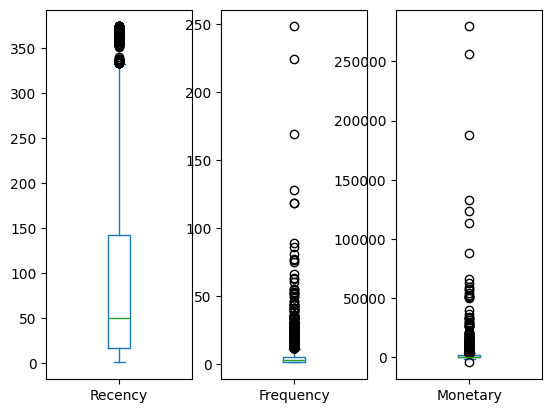

In [178]:
rfm.plot(kind = 'box',subplots = True)

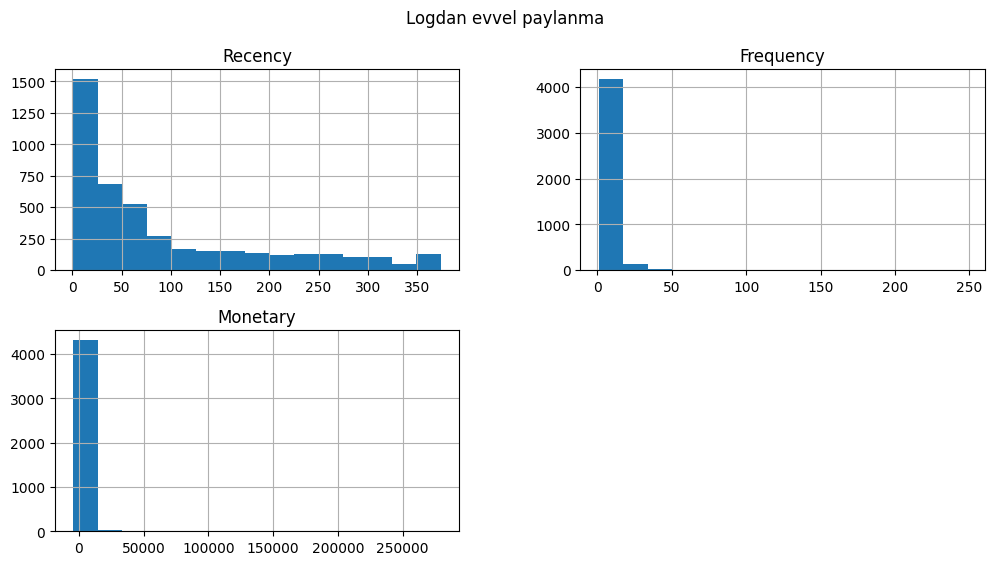

In [179]:
rfm.hist(bins = 15,figsize =(12,6))
plt.suptitle('Logdan evvel paylanma')
plt.show()

In [180]:
rfm_log = np.log1p(rfm)

,0
Recency,"Axes(0.125,0.11;0.227941x0.77)"
Frequency,"Axes(0.398529,0.11;0.227941x0.77)"
Monetary,"Axes(0.672059,0.11;0.227941x0.77)"


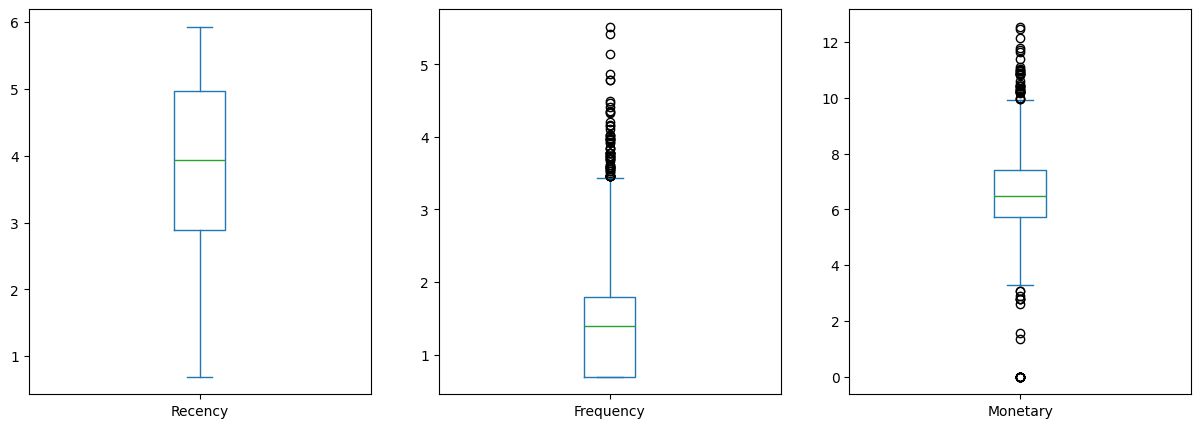

In [181]:
rfm_log.plot(kind = 'box',subplots = True,figsize = (15,5),layout = (1,3))

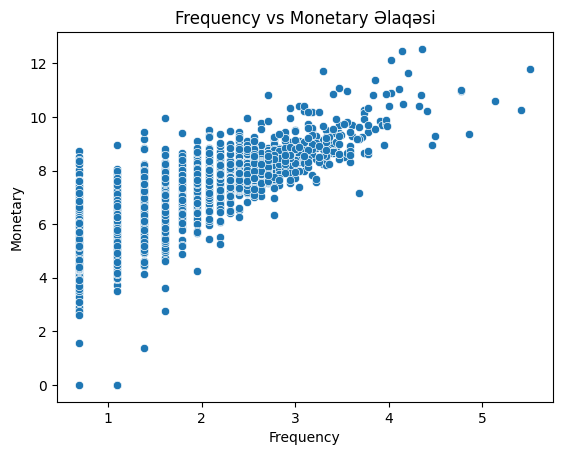

In [182]:
sns.scatterplot(data = rfm_log,x = 'Frequency',y = 'Monetary')
plt.title('Frequency vs Monetary Əlaqəsi')
plt.show()

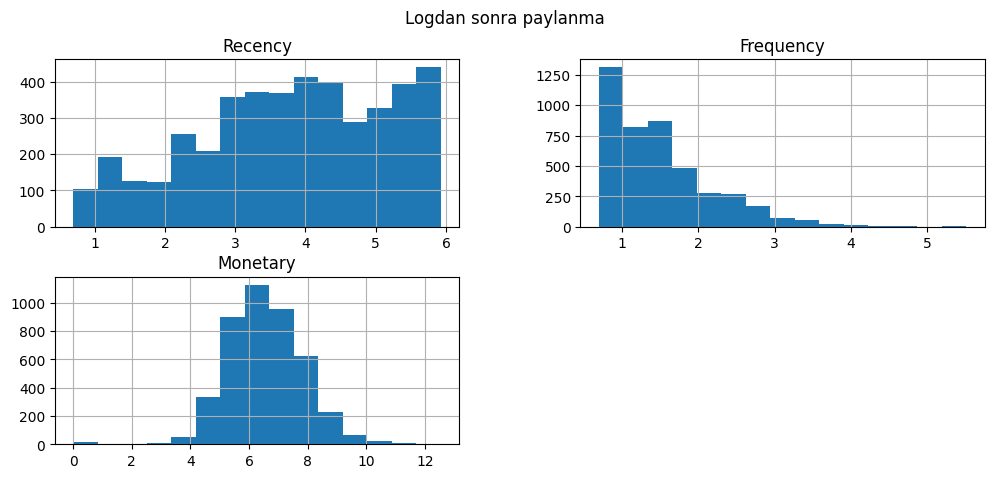

In [183]:
rfm_log.hist(bins = 15,figsize = (12,5))
plt.suptitle('Logdan sonra paylanma')
plt.show()

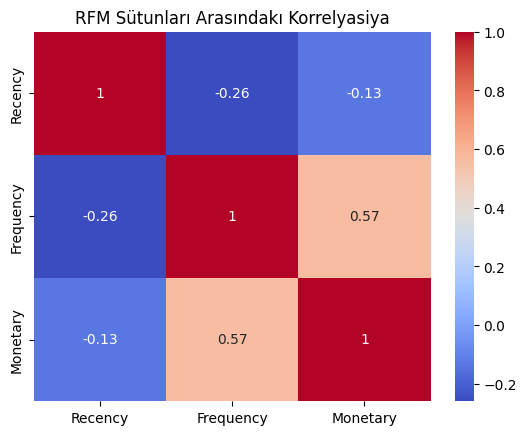

In [184]:
# Sütunlar arası korrelyasiya
sns.heatmap(rfm.corr(), annot=True, cmap='coolwarm')
plt.title('RFM Sütunları Arasındakı Korrelyasiya')
plt.show()

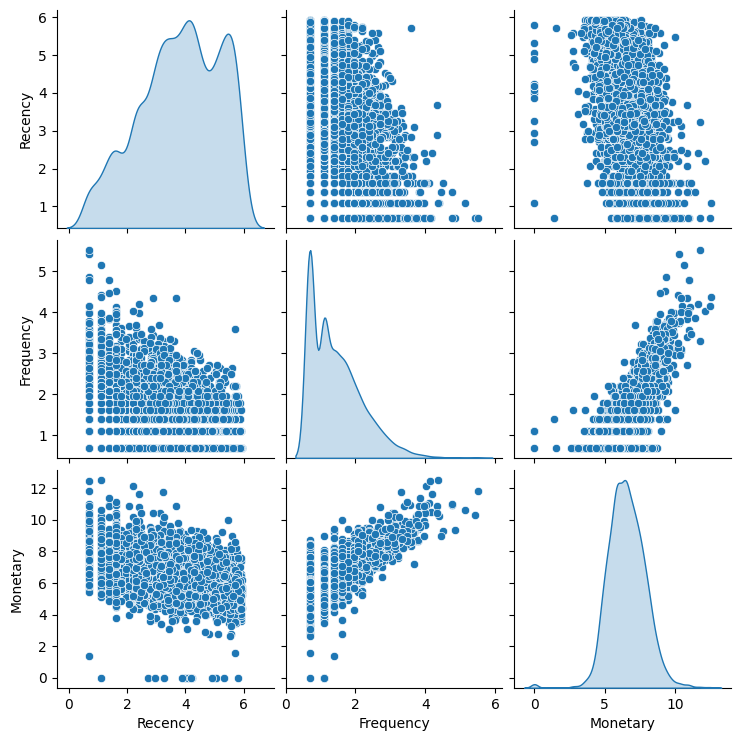

In [185]:
sns.pairplot(rfm_log,diag_kind= 'kde')
plt.show()

In [186]:
print("Hər sütundakı null sayı:\n", rfm_log.isnull().sum())

Hər sütundakı null sayı:
 Recency       0
Frequency     0
Monetary     41
dtype: int64


In [187]:
rfm = rfm.dropna(subset=['Monetary'])
rfm_log = rfm_log.dropna(subset=['Monetary'])

In [188]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

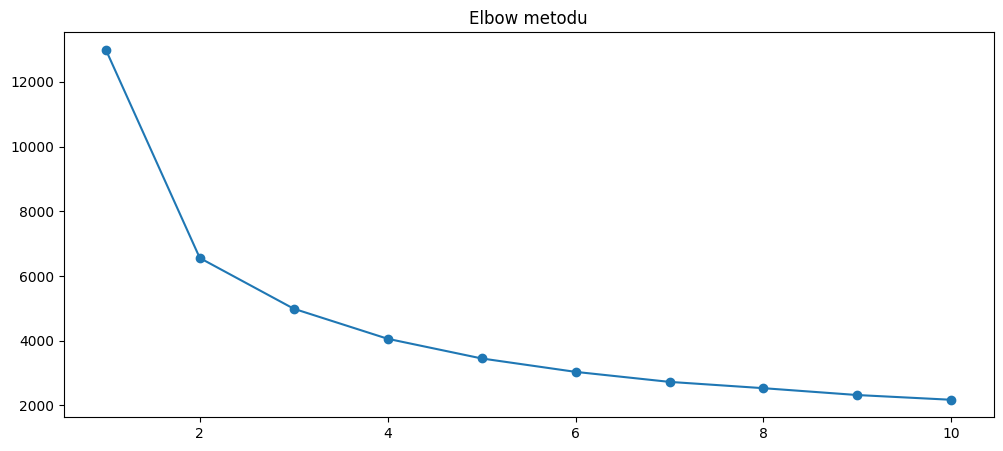

In [189]:
inertia = []
K = range(1,11)
for k in K:
  model = KMeans(n_clusters= k,random_state= 42)
  model.fit(rfm_scaled)
  inertia.append(model.inertia_)
plt.figure(figsize = (12,5))
plt.plot(K,inertia,marker = 'o')
plt.title('Elbow metodu')
plt.show()

In [190]:
rfm = rfm.loc[rfm_log.index]

In [191]:
kmeans = KMeans(n_clusters = 4,random_state = 42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

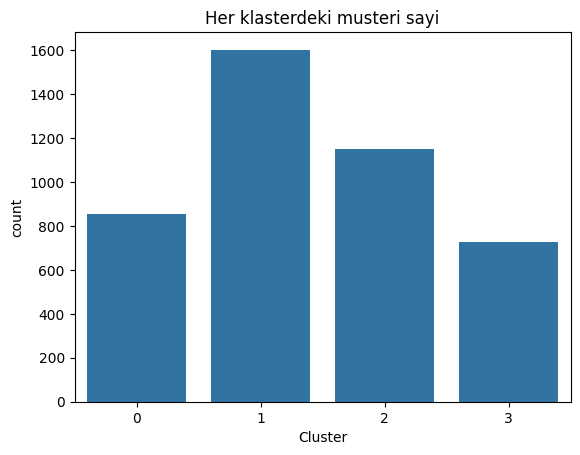

In [192]:
sns.countplot(x = 'Cluster',data = rfm)
plt.title('Her klasterdeki musteri sayi')
plt.show()

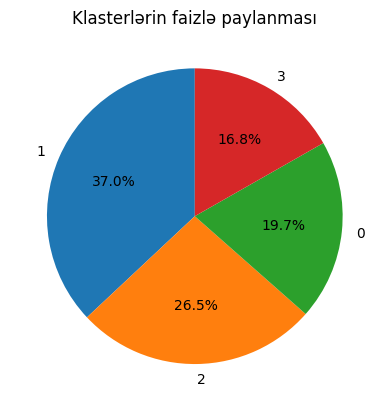

In [193]:
rfm['Cluster'].value_counts().plot.pie(startangle = 90,autopct = '%1.1f%%')
plt.title('Klasterlərin faizlə paylanması')
plt.ylabel('')
plt.show()

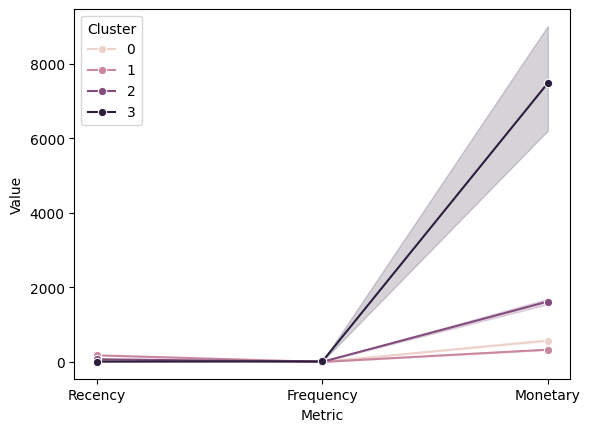

In [194]:
cluster_melt = pd.melt(rfm.reset_index(),
                       id_vars = ['Cluster'],
                       value_vars = ['Recency','Frequency','Monetary'],
                       var_name = 'Metric',value_name = 'Value'
                       )
sns.lineplot(data = cluster_melt,x = 'Metric',y = 'Value',hue = 'Cluster',marker = 'o')
plt.show()

In [195]:
rfm['Segment'] = rfm['Cluster'].map({
    3: 'VIP',
    2: 'Loyal',
    1: 'Potential',
    0: 'At Risk'
})


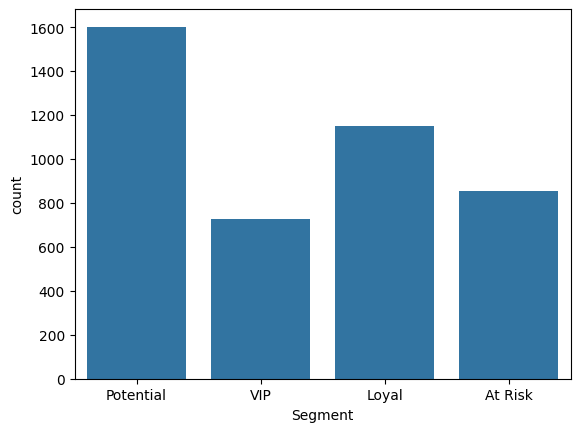

In [196]:
sns.countplot(data = rfm, x = 'Segment')
plt.show()

In [197]:
centroid = kmeans.cluster_centers_

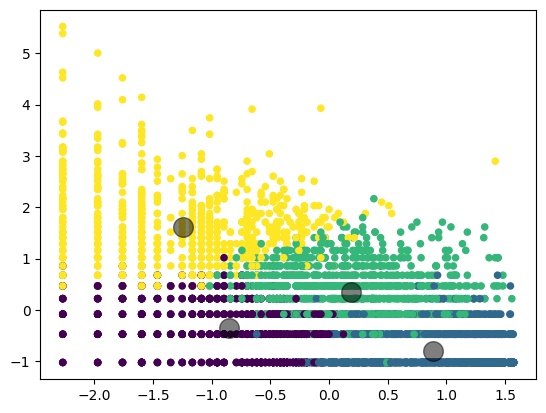

In [198]:
plt.scatter(rfm_scaled[:,0],rfm_scaled[:,1],c = rfm['Cluster'], s = 20,cmap = 'viridis')
plt.scatter(centroid[:,0],centroid[:,1],c = 'black',s = 200,alpha = 0.5)
plt.show()

In [199]:
score = silhouette_score(rfm_scaled,kmeans.labels_)
score

np.float64(0.3340013301472787)

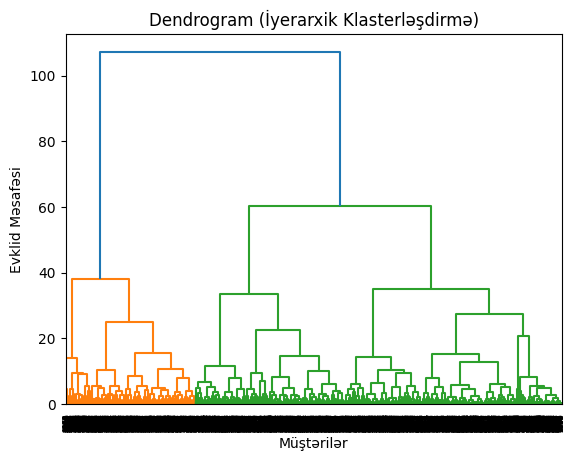

In [200]:
dendrogram = sch.dendrogram(sch.linkage(rfm_scaled,method = 'ward'))
plt.title('Dendrogram (İyerarxik Klasterləşdirmə)')
plt.xlabel('Müştərilər')
plt.ylabel('Evklid Məsafəsi')
plt.show()

In [201]:
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
hierarchical_clusters = hc.fit_predict(rfm_scaled)

In [202]:
score_hierarxik =  silhouette_score(rfm_scaled,hierarchical_clusters)
score_hierarxik

np.float64(0.2632861798233946)

In [203]:



dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(rfm_scaled)



In [204]:
dbscan_score = silhouette_score(rfm_scaled,dbscan_clusters)
print(dbscan_score)

0.20624581965362349
